In [3]:
pip install python-pptx

   ---------------------------------------- 0.0/472.8 kB ? eta -:--:--
   --------------------------------------- 472.8/472.8 kB 14.9 MB/s eta 0:00:00
   ---------------------------------------- 0.0/175.3 kB ? eta -:--:--
   ---------------------------------------- 175.3/175.3 kB 5.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [8]:
from pptx import Presentation
from pptx.util import Inches, Pt
from pptx.enum.shapes import MSO_SHAPE
from pptx.enum.text import PP_ALIGN, MSO_ANCHOR
from pptx.dml.color import RGBColor
from pptx.enum.text import MSO_AUTO_SIZE
import os

# =========================================================
# CONFIG
# =========================================================
SAVE_PATH = r"B:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding\poster_capstone_styled.pptx"

# Poster size: 42 x 30 inches, landscape
POSTER_W = 42
POSTER_H = 30

# Colors (close to the styled PNG)
NAVY = RGBColor(14, 28, 45)         # background
TEAL = RGBColor(41, 128, 185)       # accent
LIGHT_TEAL = RGBColor(224, 244, 247)
WHITE = RGBColor(255, 255, 255)
TEXT_DARK = RGBColor(30, 40, 55)
MUTED = RGBColor(95, 110, 125)
RED = RGBColor(192, 57, 43)
GREEN = RGBColor(39, 174, 96)
GOLD = RGBColor(243, 156, 18)
LIGHT_GRAY = RGBColor(240, 243, 247)
MID_GRAY = RGBColor(210, 218, 226)

# =========================================================
# CREATE PPT
# =========================================================
prs = Presentation()
prs.slide_width = Inches(POSTER_W)
prs.slide_height = Inches(POSTER_H)

slide = prs.slides.add_slide(prs.slide_layouts[6])

# =========================================================
# HELPERS
# =========================================================
def add_full_background(slide, color):
    bg = slide.shapes.add_shape(
        MSO_SHAPE.RECTANGLE, 0, 0, prs.slide_width, prs.slide_height
    )
    bg.fill.solid()
    bg.fill.fore_color.rgb = color
    bg.line.fill.background()
    return bg

def add_rounded_panel(slide, left, top, width, height, fill=WHITE, line=WHITE, radius=True):
    shape_type = MSO_SHAPE.ROUNDED_RECTANGLE if radius else MSO_SHAPE.RECTANGLE
    shp = slide.shapes.add_shape(
        shape_type, Inches(left), Inches(top), Inches(width), Inches(height)
    )
    shp.fill.solid()
    shp.fill.fore_color.rgb = fill
    shp.line.color.rgb = line
    shp.line.width = Pt(1.25)
    return shp

def add_header_bar(slide, left, top, width, height, text, fill=TEAL, font_size=24):
    bar = slide.shapes.add_shape(
        MSO_SHAPE.ROUNDED_RECTANGLE, Inches(left), Inches(top), Inches(width), Inches(height)
    )
    bar.fill.solid()
    bar.fill.fore_color.rgb = fill
    bar.line.fill.background()

    tf = bar.text_frame
    tf.clear()
    p = tf.paragraphs[0]
    run = p.add_run()
    run.text = text
    run.font.size = Pt(font_size)
    run.font.bold = True
    run.font.color.rgb = WHITE
    p.alignment = PP_ALIGN.CENTER
    tf.vertical_anchor = MSO_ANCHOR.MIDDLE
    return bar

def add_textbox(slide, left, top, width, height, text, font_size=18, bold=False,
                color=TEXT_DARK, align=PP_ALIGN.LEFT, margin=0.08):
    tb = slide.shapes.add_textbox(Inches(left), Inches(top), Inches(width), Inches(height))
    tf = tb.text_frame
    tf.word_wrap = True
    tf.margin_left = Inches(margin)
    tf.margin_right = Inches(margin)
    tf.margin_top = Inches(margin)
    tf.margin_bottom = Inches(margin)
    tf.auto_size = MSO_AUTO_SIZE.NONE
    tf.vertical_anchor = MSO_ANCHOR.TOP

    lines = text.split("\n")
    first = True
    for line in lines:
        if first:
            p = tf.paragraphs[0]
            first = False
        else:
            p = tf.add_paragraph()
        run = p.add_run()
        run.text = line
        run.font.size = Pt(font_size)
        run.font.bold = bold
        run.font.color.rgb = color
        p.alignment = align
        p.space_after = Pt(2)
    return tb

def add_bullets(slide, left, top, width, height, bullets, font_size=17,
                bullet_color=TEXT_DARK, text_color=TEXT_DARK):
    tb = slide.shapes.add_textbox(Inches(left), Inches(top), Inches(width), Inches(height))
    tf = tb.text_frame
    tf.word_wrap = True
    tf.margin_left = Inches(0.12)
    tf.margin_right = Inches(0.08)
    tf.margin_top = Inches(0.05)
    tf.margin_bottom = Inches(0.05)

    for i, item in enumerate(bullets):
        p = tf.paragraphs[0] if i == 0 else tf.add_paragraph()
        p.text = item
        p.level = 0
        p.font.size = Pt(font_size)
        p.font.color.rgb = text_color
        p.bullet = True
        p.space_after = Pt(4)
    return tb

def add_placeholder_plot(slide, left, top, width, height, label):
    shp = slide.shapes.add_shape(
        MSO_SHAPE.RECTANGLE, Inches(left), Inches(top), Inches(width), Inches(height)
    )
    shp.fill.solid()
    shp.fill.fore_color.rgb = LIGHT_GRAY
    shp.line.color.rgb = MID_GRAY
    shp.line.width = Pt(1.5)

    tf = shp.text_frame
    tf.clear()
    p = tf.paragraphs[0]
    run = p.add_run()
    run.text = label
    run.font.size = Pt(22)
    run.font.bold = True
    run.font.color.rgb = MUTED
    p.alignment = PP_ALIGN.CENTER
    tf.vertical_anchor = MSO_ANCHOR.MIDDLE
    return shp

def add_small_tag(slide, left, top, width, height, text, fill=LIGHT_TEAL, color=TEAL):
    tag = slide.shapes.add_shape(
        MSO_SHAPE.ROUNDED_RECTANGLE, Inches(left), Inches(top), Inches(width), Inches(height)
    )
    tag.fill.solid()
    tag.fill.fore_color.rgb = fill
    tag.line.fill.background()

    tf = tag.text_frame
    p = tf.paragraphs[0]
    run = p.add_run()
    run.text = text
    run.font.size = Pt(15)
    run.font.bold = True
    run.font.color.rgb = color
    p.alignment = PP_ALIGN.CENTER
    tf.vertical_anchor = MSO_ANCHOR.MIDDLE
    return tag

def add_table_like_box(slide, left, top, width, height):
    # Main container
    panel = slide.shapes.add_shape(
        MSO_SHAPE.RECTANGLE, Inches(left), Inches(top), Inches(width), Inches(height)
    )
    panel.fill.solid()
    panel.fill.fore_color.rgb = WHITE
    panel.line.color.rgb = MID_GRAY
    panel.line.width = Pt(1.2)
    return panel

# =========================================================
# BACKGROUND
# =========================================================
add_full_background(slide, NAVY)

# Optional subtle "search bar" style top motif
search_bar = slide.shapes.add_shape(
    MSO_SHAPE.ROUNDED_RECTANGLE, Inches(12), Inches(0.45), Inches(18), Inches(0.6)
)
search_bar.fill.solid()
search_bar.fill.fore_color.rgb = RGBColor(245, 247, 250)
search_bar.line.fill.background()

tf = search_bar.text_frame
p = tf.paragraphs[0]
r = p.add_run()
r.text = "failure@5  persistent ranking failures  LETOR MQ2007"
r.font.size = Pt(18)
r.font.color.rgb = MUTED
p.alignment = PP_ALIGN.LEFT

# =========================================================
# TITLE AREA
# =========================================================
title_panel = add_rounded_panel(slide, 0.8, 0.8, 40.4, 2.0, fill=WHITE, line=WHITE)
add_textbox(
    slide, 1.2, 1.0, 28, 0.7,
    "Analyzing Ranking Failures and Visibility in Learning-to-Rank Systems",
    font_size=28, bold=True, color=TEXT_DARK
)
add_textbox(
    slide, 1.2, 1.55, 20, 0.4,
    "Capstone Project | LETOR 4.0 (MQ2007, MQ2008) | Kushal Marahatta, Harshil Watts, Mahesh Varma Sangaraju",
    font_size=14, color=MUTED
)
add_small_tag(slide, 31.5, 1.1, 8.2, 0.55, "Failure analysis, not model benchmarking")

# =========================================================
# ROW 1
# =========================================================
# Motivation
add_rounded_panel(slide, 0.9, 3.0, 12.2, 5.2)
add_header_bar(slide, 1.1, 3.15, 11.8, 0.55, "Motivation")
add_bullets(slide, 1.2, 3.95, 11.5, 3.8, [
    "Strong average ranking metrics can still hide query-level failures.",
    "Users care about what appears in the top few results, not only overall ranking quality.",
    "This project studies when and why no relevant document appears in top-K.",
    "Main question: are some failures structural rather than model-specific?"
], font_size=17)

# How Ranking Works
add_rounded_panel(slide, 14.0, 3.0, 12.2, 5.2)
add_header_bar(slide, 14.2, 3.15, 11.8, 0.55, "How Ranking Works")
add_bullets(slide, 14.3, 3.95, 11.4, 3.8, [
    "Each query has many candidate documents.",
    "Each document receives a score from its feature values.",
    "Higher score -> higher rank.",
    "Failure@5 = no document with label >= 1 appears in the top 5.",
    "This captures visibility failure, not just average ranking quality."
], font_size=17)

# Model Results Table
add_rounded_panel(slide, 27.1, 3.0, 13.0, 5.2)
add_header_bar(slide, 27.3, 3.15, 12.6, 0.55, "Model Performance vs Failure")
table_box = add_table_like_box(slide, 27.55, 4.0, 12.1, 2.1)

# Draw simple manual table lines
# horizontal
slide.shapes.add_shape(MSO_SHAPE.RECTANGLE, Inches(27.55), Inches(4.45), Inches(12.1), Inches(0.01)).fill.solid()
slide.shapes[-1].fill.fore_color.rgb = MID_GRAY
slide.shapes[-1].line.fill.background()

for y in [4.95, 5.45]:
    line = slide.shapes.add_shape(MSO_SHAPE.RECTANGLE, Inches(27.55), Inches(y), Inches(12.1), Inches(0.01))
    line.fill.solid()
    line.fill.fore_color.rgb = MID_GRAY
    line.line.fill.background()

for x in [31.2, 34.0, 36.6]:
    line = slide.shapes.add_shape(MSO_SHAPE.RECTANGLE, Inches(x), Inches(4.0), Inches(0.01), Inches(2.1))
    line.fill.solid()
    line.fill.fore_color.rgb = MID_GRAY
    line.line.fill.background()

# table text
add_textbox(slide, 27.7, 4.07, 3.2, 0.3, "Model", font_size=14, bold=True)
add_textbox(slide, 31.35, 4.07, 2.4, 0.3, "P@5", font_size=14, bold=True, align=PP_ALIGN.CENTER)
add_textbox(slide, 34.1, 4.07, 2.3, 0.3, "NDCG@5", font_size=14, bold=True, align=PP_ALIGN.CENTER)
add_textbox(slide, 36.75, 4.07, 2.6, 0.3, "Failure@5", font_size=14, bold=True, align=PP_ALIGN.CENTER)

# Replace XX with your actual values
rows = [
    ("Pointwise (baseline)", "XX", "XX", "XX"),
    ("Pairwise", "XX", "XX", "XX"),
    ("LightGBM", "XX", "XX", "XX"),
]
row_ys = [4.52, 5.02, 5.52]
for (name, p5, ndcg, fail), y in zip(rows, row_ys):
    add_textbox(slide, 27.7, y, 3.25, 0.26, name, font_size=13)
    add_textbox(slide, 31.35, y, 2.3, 0.26, p5, font_size=13, align=PP_ALIGN.CENTER)
    add_textbox(slide, 34.1, y, 2.2, 0.26, ndcg, font_size=13, align=PP_ALIGN.CENTER)
    add_textbox(slide, 36.75, y, 2.3, 0.26, fail, font_size=13, align=PP_ALIGN.CENTER)

add_textbox(
    slide, 27.55, 6.35, 12.0, 1.15,
    "Key message: stronger models may improve NDCG, but they do not consistently reduce Failure@5.",
    font_size=16, bold=True, color=RED, align=PP_ALIGN.CENTER
)

# =========================================================
# ROW 2
# =========================================================
# Top-K Visibility
add_rounded_panel(slide, 0.9, 8.7, 12.2, 10.3)
add_header_bar(slide, 1.1, 8.9, 11.8, 0.55, "Top-K Visibility")
add_placeholder_plot(slide, 1.25, 9.8, 11.5, 6.1, "INSERT STEP CURVE:\n% queries with at least one relevant doc in top-K")
add_textbox(
    slide, 1.2, 16.2, 11.5, 1.5,
    "Interpretation: relevant documents often appear late, which means early ranks can fail even when some relevance exists deeper in the list.",
    font_size=16, color=TEXT_DARK
)

# Failure Boundary (MAIN CENTERPIECE)
add_rounded_panel(slide, 14.0, 8.7, 18.6, 10.3)
add_header_bar(slide, 14.2, 8.9, 18.2, 0.55, "Structural Region of Persistent Failures")
add_placeholder_plot(slide, 14.35, 9.8, 17.9, 6.6, "INSERT MAIN PLOT:\nX = score_gap\nY = num_relevant_1\nPersistent = red\nSuccessful = green")
add_small_tag(slide, 14.5, 16.75, 5.7, 0.45, "High-risk failure region")
add_textbox(
    slide, 14.4, 17.35, 17.7, 1.2,
    "Main finding: persistent failures cluster where queries have very few relevant documents and weak or negative score separation near the rank-5 cutoff.",
    font_size=17, bold=True, color=TEXT_DARK, align=PP_ALIGN.CENTER
)

# Why Queries Fail
add_rounded_panel(slide, 33.1, 8.7, 7.9, 10.3)
add_header_bar(slide, 33.3, 8.9, 7.5, 0.55, "Why Queries Fail")
add_bullets(slide, 33.35, 9.95, 7.2, 6.7, [
    "Very few relevant documents",
    "Often exactly one relevant document",
    "Weak score separation near top-5",
    "Relevant item falls just below visibility cutoff",
    "Better models do not reliably solve these cases"
], font_size=17)
add_textbox(
    slide, 33.45, 16.95, 7.0, 1.1,
    "Use non-causal wording: associated with, supports, suggests.",
    font_size=15, bold=True, color=RED, align=PP_ALIGN.CENTER
)

# =========================================================
# ROW 3
# =========================================================
# Case Study
add_rounded_panel(slide, 0.9, 19.5, 12.2, 7.5)
add_header_bar(slide, 1.1, 19.7, 11.8, 0.55, "Query-Level Case Study")
add_placeholder_plot(slide, 1.25, 20.6, 11.5, 4.2, "INSERT CASE STUDY PLOT:\nrank vs score\nshow relevant item below rank 5")
add_textbox(
    slide, 1.15, 25.05, 11.6, 1.1,
    "Interpretation: failure is often a near-miss rather than total collapse. The relevant document exists but remains just below the visible range.",
    font_size=15
)

# Stress Test
add_rounded_panel(slide, 14.0, 19.5, 12.2, 7.5)
add_header_bar(slide, 14.2, 19.7, 11.8, 0.55, "Synthetic Sparsity Stress Test")
add_placeholder_plot(slide, 14.35, 20.6, 11.5, 4.2, "INSERT STRESS TEST:\noriginal -> cap_rel_3 -> cap_rel_2 -> cap_rel_1")
add_textbox(
    slide, 14.15, 25.05, 11.6, 1.1,
    "Interpretation: when relevance redundancy is artificially reduced while scores stay fixed, Failure@5 tends to increase.",
    font_size=15
)

# Key Findings
add_rounded_panel(slide, 27.1, 19.5, 13.9, 7.5)
add_header_bar(slide, 27.3, 19.7, 13.5, 0.55, "Key Findings")
add_bullets(slide, 27.45, 20.65, 13.2, 5.6, [
    "Failure@5 and NDCG tell different stories.",
    "Stronger models do not reliably reduce complete ranking failures.",
    "Persistent failures exist across models, pipelines, folds, and weaker cross-dataset replication.",
    "The strongest structural signals are low num_relevant_1, exactly one relevant document, and negative score_gap.",
    "Query length is not the main driver.",
    "Per-query normalization creates tradeoffs rather than universal gains."
], font_size=16)

# =========================================================
# BOTTOM STRIP
# =========================================================
# Conclusion
add_rounded_panel(slide, 0.9, 27.35, 28.1, 1.7, fill=WHITE)
add_header_bar(slide, 1.1, 27.52, 4.3, 0.45, "Conclusion", font_size=20)
add_textbox(
    slide, 5.7, 27.58, 22.7, 0.8,
    "Some ranking failures appear structurally hard. Improving average ranking quality alone does not guarantee that relevant documents become visible in the top-K results.",
    font_size=18, bold=True, color=TEXT_DARK, align=PP_ALIGN.CENTER
)

# Limitations
add_rounded_panel(slide, 29.4, 27.35, 11.6, 1.7, fill=WHITE)
add_header_bar(slide, 29.6, 27.52, 3.9, 0.45, "Limitations", font_size=20)
add_textbox(
    slide, 33.9, 27.56, 6.5, 0.9,
    "Associational analysis; no causal claim. Exact effects vary across K, dataset, and fold.",
    font_size=15, color=TEXT_DARK, align=PP_ALIGN.CENTER
)

# =========================================================
# SAVE
# =========================================================
os.makedirs(os.path.dirname(SAVE_PATH), exist_ok=True)
prs.save(SAVE_PATH)

print("Styled poster saved to:")
print(SAVE_PATH)

Styled poster saved to:
B:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding\poster_capstone_styled.pptx


## Top k visibility curve

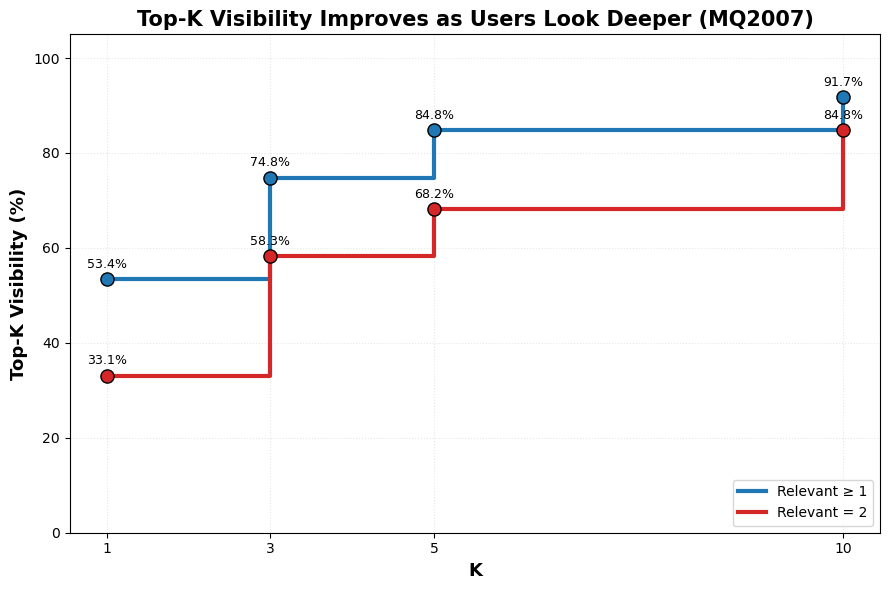

Saved: b:\Arlington\Arlington\4th_sem\Capstone\Capstone_coding\data\processed\poster_plots\poster_topk_visibility_curve.png


In [9]:
# Poster Plot 2: Top-K Visibility Curve
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
PHASE9_OUTPUT = PROJECT_ROOT / 'data' / 'processed' / 'phase9_robustness'
POSTER_OUTPUT = PROJECT_ROOT / 'data' / 'processed' / 'poster_plots'
POSTER_OUTPUT.mkdir(parents=True, exist_ok=True)

sens_file = PHASE9_OUTPUT / 'phase9_threshold_sensitivity.csv'
sens_df = pd.read_csv(sens_file)

# Keep MQ2007 only
plot_df = sens_df[sens_df['dataset'] == 2007].copy() if sens_df['dataset'].dtype != object else sens_df[sens_df['dataset'] == '2007'].copy()

plot_df['visibility_pct'] = 100 - plot_df['pct_failures']

fig, ax = plt.subplots(figsize=(9, 6))

for rel_thresh, label, color in [
    (1, 'Relevant ≥ 1', '#1f77b4'),
    (2, 'Relevant = 2', '#d62728')
]:
    sub = plot_df[plot_df['relevance_threshold'] == rel_thresh].sort_values('k')
    ax.step(
        sub['k'],
        sub['visibility_pct'],
        where='post',
        linewidth=3,
        label=label,
        color=color
    )
    ax.scatter(sub['k'], sub['visibility_pct'], s=90, color=color, edgecolors='black', zorder=3)

    for _, row in sub.iterrows():
        ax.annotate(
            f"{row['visibility_pct']:.1f}%",
            (row['k'], row['visibility_pct']),
            textcoords='offset points',
            xytext=(0, 8),
            ha='center',
            fontsize=9
        )

ax.set_xlabel('K', fontsize=13, fontweight='bold')
ax.set_ylabel('Top-K Visibility (%)', fontsize=13, fontweight='bold')
ax.set_title('Top-K Visibility Improves as Users Look Deeper (MQ2007)', fontsize=15, fontweight='bold')
ax.set_xticks([1, 3, 5, 10])
ax.set_ylim(0, 105)
ax.grid(alpha=0.3, linestyle=':')
ax.legend(fontsize=10, loc='lower right')

plt.tight_layout()
plt.savefig(POSTER_OUTPUT / 'poster_topk_visibility_curve.png', dpi=180, bbox_inches='tight')
plt.show()

print("Saved:", POSTER_OUTPUT / 'poster_topk_visibility_curve.png')